Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
입력 데이터 형태: (455, 29)
타겟 데이터 형태: (455,)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 525719.0625 - mae: 639.4487 - val_loss: 668544.2500 - val_mae: 707.1846
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 524253.5938 - mae: 638.3718 - val_loss: 666592.3750 - val_mae: 705.9757
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 522274.5938 - mae: 636.9012 - val_loss: 663499.1875 - val_mae: 704.1145
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 518995.9688 - mae: 634.5348 - val_loss: 658342.0000 - val_mae: 701.0939
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 513507.6562 - mae: 630.7138 - val_loss: 649584.6250 - val_mae: 696.0705
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 504475.0000 - mae: 624.4633 - val_loss: 634453.3750 - val_mae: 687.5567
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 489842.0312 - mae: 614.1562 - val_loss: 610336.2500 - val_mae: 673.8641
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 466637.6562 - mae: 597.8071 - v

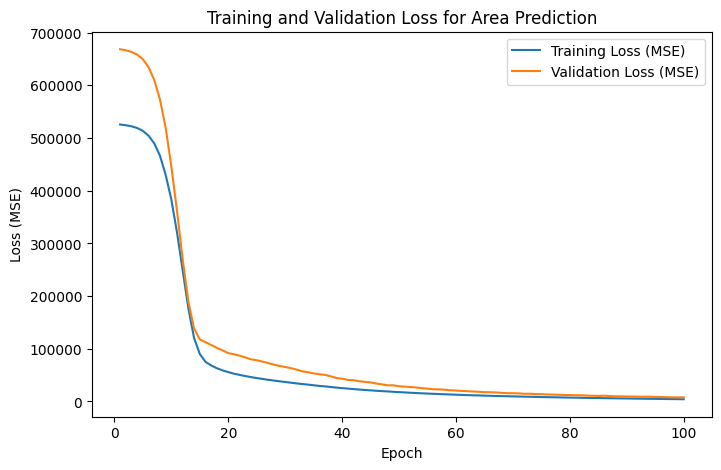


=== 종양 면적 예측 회귀 모델 평가 ===
Mean Squared Error (MSE): 7645.05
R-squared (R2 Score): 0.9280


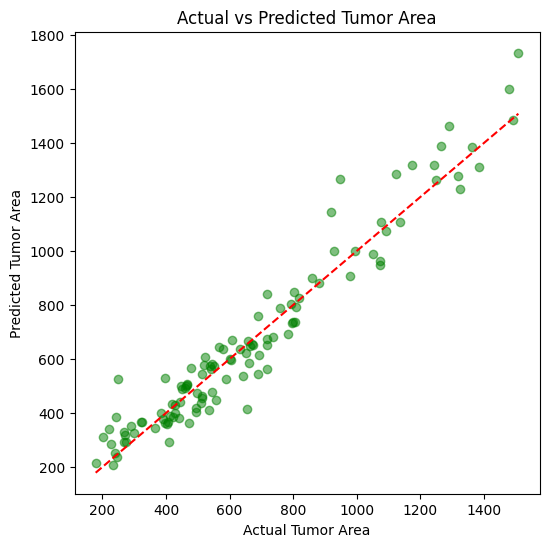

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from keras.models import Sequential
from keras.layers import Dense
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/breast_cancer.csv")

cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)


y = df['mean area']

X_data = df.drop('mean area', axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X_data)

y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("입력 데이터 형태:", X_train.shape)
print("타겟 데이터 형태:", y_train.shape)

model = Sequential()
model.add(Dense(64, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

N_EPOCHS = 100
history = model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32, validation_split=0.2, verbose=1)

y_pred = model.predict(X_test)


plt.figure(figsize=(8, 5))
plt.plot(range(1, N_EPOCHS + 1), history.history['loss'], label='Training Loss (MSE)')
plt.plot(range(1, N_EPOCHS + 1), history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training and Validation Loss for Area Prediction')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

mse_score = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== 종양 면적 예측 회귀 모델 평가 ===")
print(f"Mean Squared Error (MSE): {mse_score:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Tumor Area")
plt.ylabel("Predicted Tumor Area")
plt.title("Actual vs Predicted Tumor Area")
plt.show()